In [2]:
!pip install fastf1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1


In [3]:
from matplotlib import pyplot as plt
import fastf1
import fastf1.plotting

In [22]:
# Load the Australian Grand Prix (Round 1)
australian_gpr = fastf1.get_session(2025, 1, 'R')  # 'R' denotes the race session
australian_gpq = fastf1.get_session(2025, 1, 'Q')
australian_gpr.load()
australian_gpq.load()


# Load the Chinese Grand Prix (Round 2)
chinese_gpr = fastf1.get_session(2025, 2, 'R')
chinese_gpq = fastf1.get_session(2025, 2, 'Q')
chinese_gpr.load()
chinese_gpq.load()

core           INFO 	Loading data for Australian Grand Prix - Race [v3.5.3]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
INFO:fastf1.fastf1.req:Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core   

In [25]:
def get_driver_laps(race, quali, driver_code):
    return {
        'race': race.laps.pick_drivers(driver_code),
        'quali': quali.laps.pick_drivers(driver_code)
    }

# Define drivers and sessions
drivers = ['LEC', 'HAM']
sessions = {
    'aus': (australian_gpr, australian_gpq),
    'chi': (chinese_gpr, chinese_gpq)
}

# Get laps for all drivers and races
laps = {
    driver: {
        gp: get_driver_laps(race, quali, driver)
        for gp, (race, quali) in sessions.items()
    }
    for driver in drivers
}



In [27]:
lec_aus_race_laps = laps['LEC']['aus']['race']
ham_aus_race_laps = laps['HAM']['aus']['race']
lec_chi_race_laps = laps['LEC']['chi']['race']
ham_chi_race_laps = laps['HAM']['chi']['race']

In [28]:
lec_aus_quali_laps = laps['LEC']['aus']['quali']
ham_aus_quali_laps = laps['HAM']['aus']['quali']
lec_chi_quali_laps = laps['LEC']['chi']['quali']
ham_chi_quali_laps = laps['HAM']['chi']['quali']

# Qualifying Performance for 2025

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

Fastest Quali Lap Times:
Leclerc - Australia: 0 days 00:01:15.755000 | China: 0 days 00:01:31.021000
Hamilton - Australia: 0 days 00:01:15.919000 | China: 0 days 00:01:30.927000


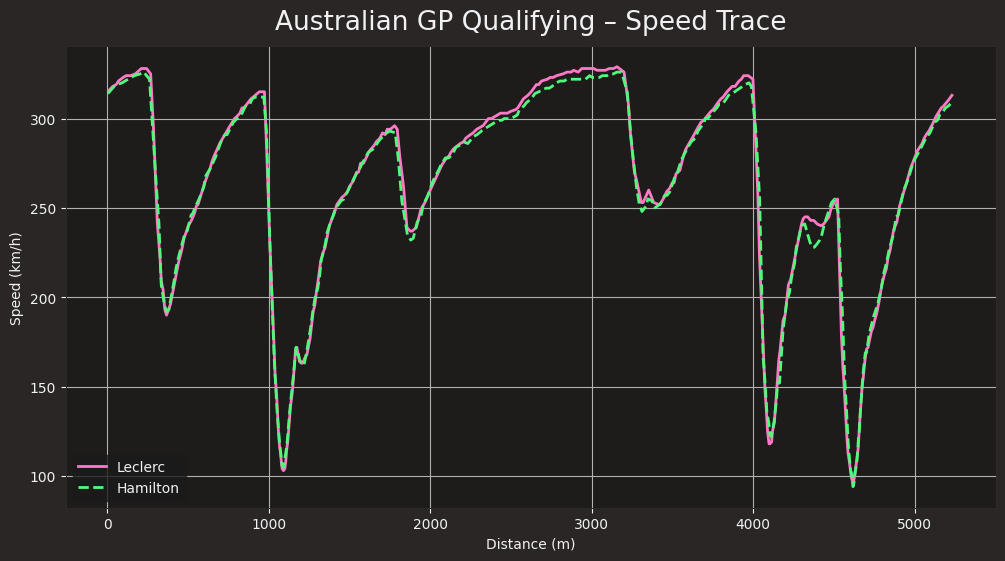

In [52]:
# 1. Get fastest quali laps for each driver in each race
lec_fastest_aus = lec_aus_quali_laps.pick_fastest()
ham_fastest_aus = ham_aus_quali_laps.pick_fastest()

lec_fastest_chi = lec_chi_quali_laps.pick_fastest()
ham_fastest_chi = ham_chi_quali_laps.pick_fastest()

# 2. Show lap time summary
print("Fastest Quali Lap Times:")
print(f"Leclerc - Australia: {lec_fastest_aus['LapTime']} | China: {lec_fastest_chi['LapTime']}")
print(f"Hamilton - Australia: {ham_fastest_aus['LapTime']} | China: {ham_fastest_chi['LapTime']}")

# 3. Load telemetry
lec_tel_aus = lec_fastest_aus.get_car_data().add_distance()
ham_tel_aus = ham_fastest_aus.get_car_data().add_distance()
lec_tel_chi = lec_fastest_chi.get_car_data().add_distance()
ham_tel_chi = ham_fastest_chi.get_car_data().add_distance()

# 4. SPEED TRACE COMPARISON – Australian GP
plt.figure()
plt.plot(lec_tel_aus['Distance'], lec_tel_aus['Speed'], label='Leclerc', linewidth=2)
plt.plot(ham_tel_aus['Distance'], ham_tel_aus['Speed'], label='Hamilton', linestyle='--', linewidth=2)
plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.title("Australian GP Qualifying – Speed Trace")
plt.legend()
plt.show()

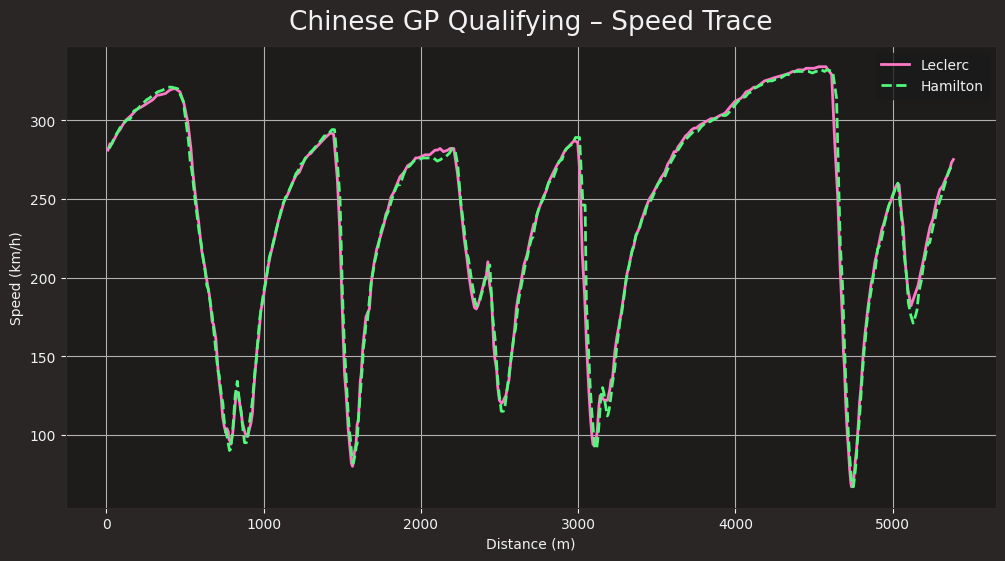

In [51]:
# SPEED TRACE COMPARISON – Chinese GP
plt.figure()
plt.plot(lec_tel_chi['Distance'], lec_tel_chi['Speed'], label='Leclerc', linewidth=2)
plt.plot(ham_tel_chi['Distance'], ham_tel_chi['Speed'], label='Hamilton', linestyle='--', linewidth=2)
plt.xlabel("Distance (m)")
plt.ylabel("Speed (km/h)")
plt.title("Chinese GP Qualifying – Speed Trace")
plt.legend()
plt.show()

In [44]:
import numpy as np
# Convert sector times to seconds for plotting
def sector_times_in_seconds(lap):
    return [
        lap['Sector1Time'].total_seconds(),
        lap['Sector2Time'].total_seconds(),
        lap['Sector3Time'].total_seconds()
    ]

# Get sector times for each lap
lec_sectors_aus = sector_times_in_seconds(lec_fastest_aus)
ham_sectors_aus = sector_times_in_seconds(ham_fastest_aus)

lec_sectors_chi = sector_times_in_seconds(lec_fastest_chi)
ham_sectors_chi = sector_times_in_seconds(ham_fastest_chi)

# Print raw values
print("\nSector Times (in seconds):")
print("Australian GP:")
print(f"  Leclerc:  S1: {lec_sectors_aus[0]:.3f}, S2: {lec_sectors_aus[1]:.3f}, S3: {lec_sectors_aus[2]:.3f}")
print(f"  Hamilton: S1: {ham_sectors_aus[0]:.3f}, S2: {ham_sectors_aus[1]:.3f}, S3: {ham_sectors_aus[2]:.3f}")

print("Chinese GP:")
print(f"  Leclerc:  S1: {lec_sectors_chi[0]:.3f}, S2: {lec_sectors_chi[1]:.3f}, S3: {lec_sectors_chi[2]:.3f}")
print(f"  Hamilton: S1: {ham_sectors_chi[0]:.3f}, S2: {ham_sectors_chi[1]:.3f}, S3: {ham_sectors_chi[2]:.3f}")



Sector Times (in seconds):
Australian GP:
  Leclerc:  S1: 26.194, S2: 17.025, S3: 32.536
  Hamilton: S1: 26.150, S2: 17.223, S3: 32.546
Chinese GP:
  Leclerc:  S1: 24.094, S2: 27.355, S3: 39.572
  Hamilton: S1: 24.148, S2: 27.175, S3: 39.604


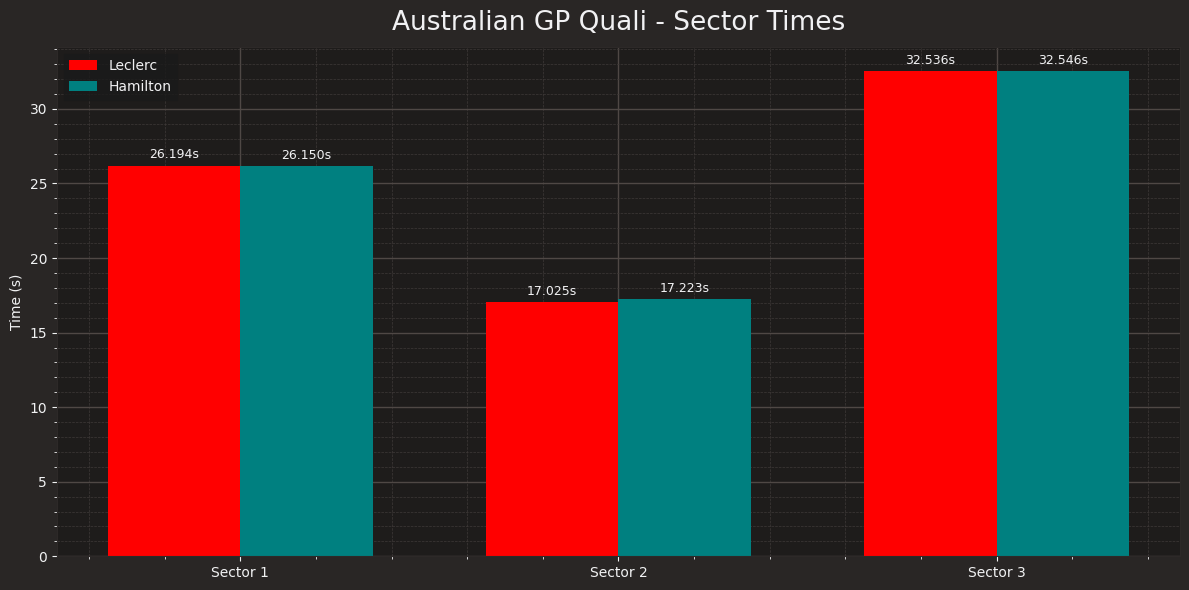

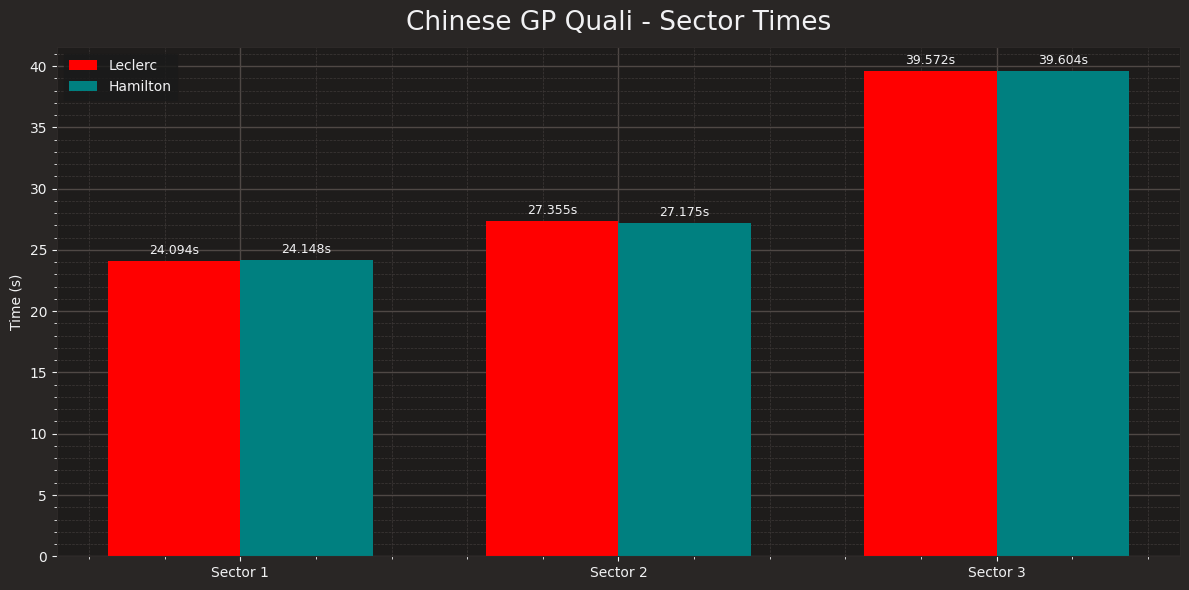

In [50]:
def add_bar_labels(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}s',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Offset text above bar
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Create bar plots for each race
labels = ['Sector 1', 'Sector 2', 'Sector 3']
x = np.arange(len(labels))
width = 0.35

# Australian GP bar plot
fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, lec_sectors_aus, width, label='Leclerc',color="red")
bars2 = ax.bar(x + width/2, ham_sectors_aus, width, label='Hamilton',color="teal")

ax.set_ylabel('Time (s)')
ax.set_title('Australian GP Quali - Sector Times')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

plt.tight_layout()
plt.show()

# Chinese GP bar plot
fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, lec_sectors_chi, width, label='Leclerc',color="red")
bars2 = ax.bar(x + width/2, ham_sectors_chi, width, label='Hamilton',color="teal")

ax.set_ylabel('Time (s)')
ax.set_title('Chinese GP Quali - Sector Times')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

plt.tight_layout()
plt.show()

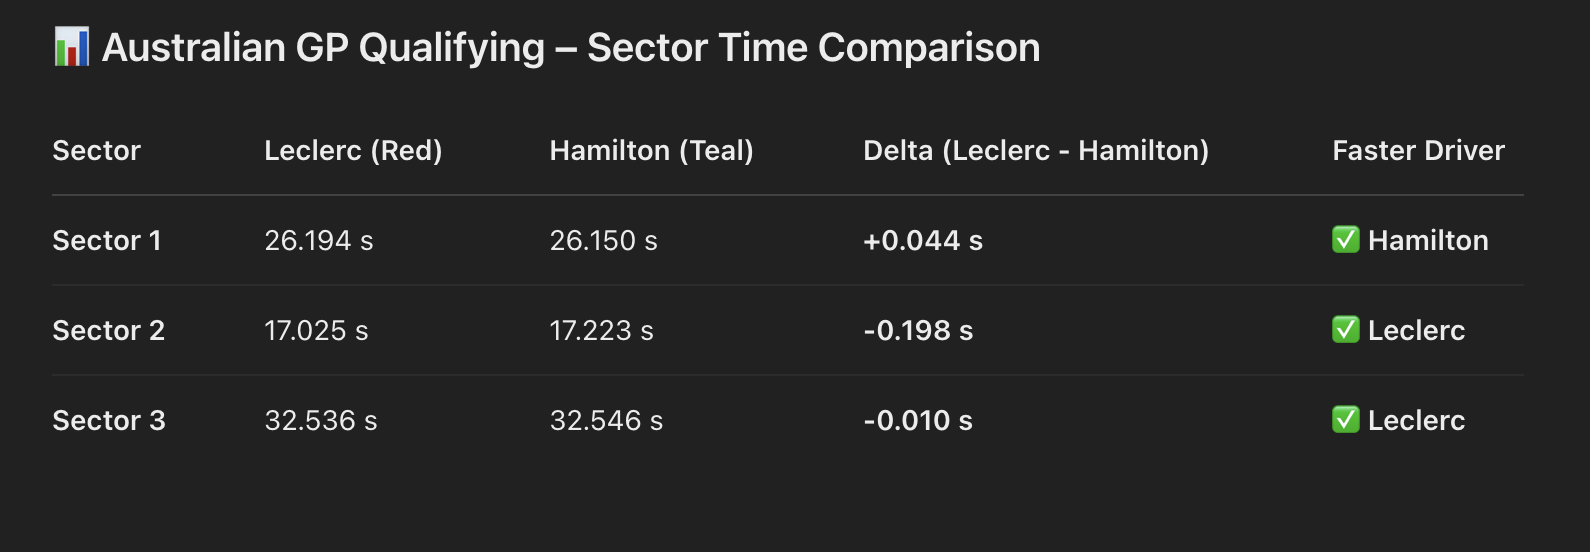

**Leclerc was faster overall in qualifying at the AUS GP by about 0.164s, with Sector 2 being his strongest with about 0.198s faster time.**

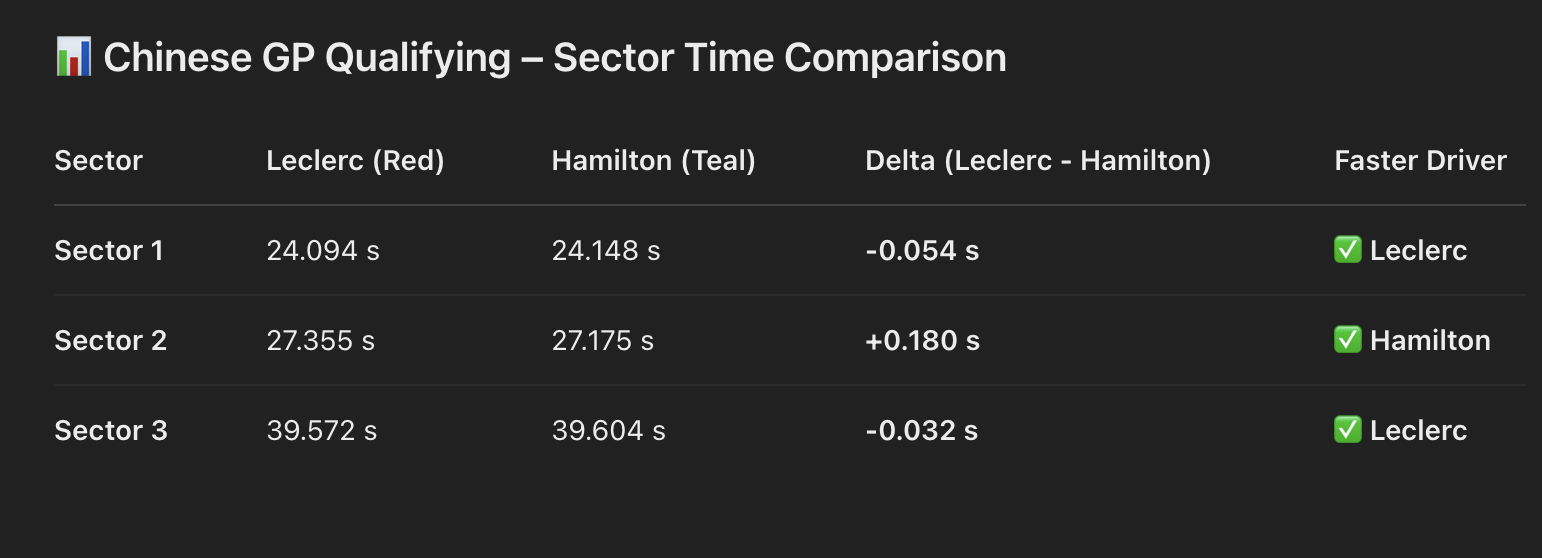

**Overall, Hamilton was faster in the Chinese GP Qualifiers overall by ~0.094s, with Sector 2 being his strongest.**




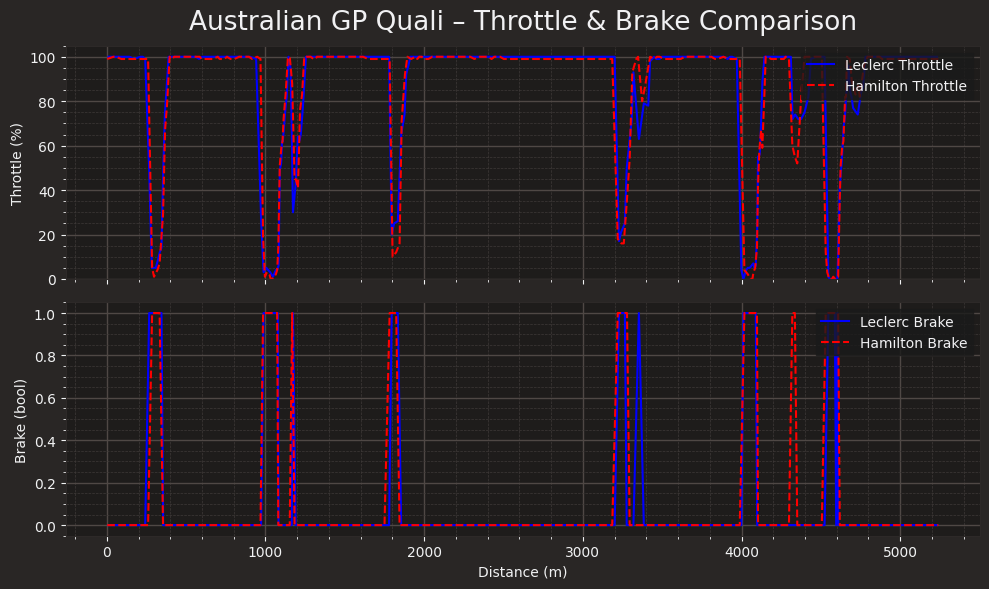

In [41]:
# BRAKE & THROTTLE COMPARISON – Australia GP
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

# Throttle subplot
ax1.plot(lec_tel_aus['Distance'], lec_tel_aus['Throttle'], label='Leclerc Throttle', color='blue')
ax1.plot(ham_tel_aus['Distance'], ham_tel_aus['Throttle'], label='Hamilton Throttle', color='red', linestyle='--')
ax1.set_ylabel('Throttle (%)')
ax1.set_ylim(0, 105)
ax1.set_title('Australian GP Quali – Throttle & Brake Comparison')
ax1.legend(loc='upper right')
ax1.grid(True)

# Brake subplot
ax2.plot(lec_tel_aus['Distance'], lec_tel_aus['Brake'], label='Leclerc Brake', color='blue')
ax2.plot(ham_tel_aus['Distance'], ham_tel_aus['Brake'], label='Hamilton Brake', color='red', linestyle='--')
ax2.set_ylabel('Brake (bool)')
ax2.set_xlabel('Distance (m)')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()

1. Leclerc seems to apply throttle slightly more aggressively out of some corners, reaching 100% quicker than Hamilton at a few points (e.g., near 1200m and 3600m).

2. Hamilton appears to lift earlier than Leclerc before braking in some zones, which might mean more controlled or conservative entry.

3. Both drivers brake at nearly identical points, confirming optimized lines through corners.

4. Around 2600-2800m and 4200-4400m, Leclerc brakes slightly earlier or harder, which might indicate a more aggressive braking strategy in certain corners.

5. Subtle differences reflects the individual driving styles and may explain how Leclerc gained time in Sectors 2 and 3 during qualifying



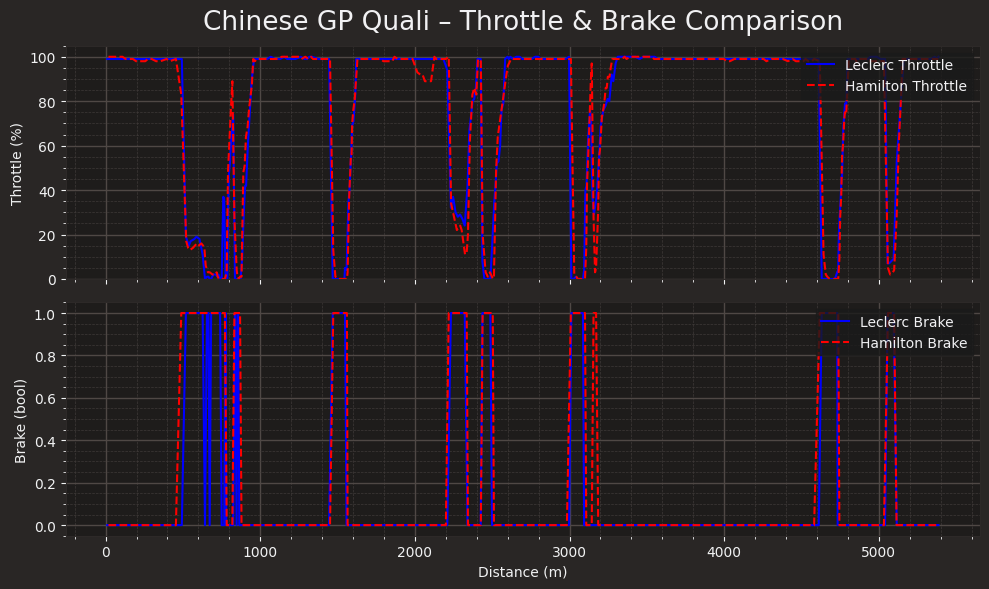

In [40]:
# BRAKE & THROTTLE COMPARISON – Chinese GP
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

# Throttle subplot
ax1.plot(lec_tel_chi['Distance'], lec_tel_chi['Throttle'], label='Leclerc Throttle', color='blue')
ax1.plot(ham_tel_chi['Distance'], ham_tel_chi['Throttle'], label='Hamilton Throttle', color='red', linestyle='--')
ax1.set_ylabel('Throttle (%)')
ax1.set_ylim(0, 105)
ax1.set_title('Chinese GP Quali – Throttle & Brake Comparison')
ax1.legend(loc='upper right')
ax1.grid(True)

# Brake subplot
ax2.plot(lec_tel_chi['Distance'], lec_tel_chi['Brake'], label='Leclerc Brake', color='blue')
ax2.plot(ham_tel_chi['Distance'], ham_tel_chi['Brake'], label='Hamilton Brake', color='red', linestyle='--')
ax2.set_ylabel('Brake (bool)')
ax2.set_xlabel('Distance (m)')
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc='upper right')
ax2.grid(True)

plt.tight_layout()
plt.show()


1. Between 2200-3000m, Leclerc's throttle appears to ramp up more gradually in at least one corner sequence, while Hamilton punches to 100% a bit more quickly.

2. Overall, Leclerc seems slightly smoother or more progressive in a few throttle zones, which may reflect a more traction-friendly exit.

3. Around 750-900m, Hamilton brakes earlier and holds it slightly longer than Leclerc — perhaps explaining why he lost a bit in Sector 1.

4. Leclerc has sharper, more distinct braking around 3000-3200m, while Hamilton trails slightly more gradually.





## **Ferrari's qualifying package looks well-balanced and aggressive, with:** ##
*   Strong late braking.
*   Predictable throttle behavior.
*   Good traction out of slow corners.

Ferrari likely has strong low-speed acceleration and downforce, helping in tight corners and complex S2 sections.

The Ferrari power unit + chassis combo allows for aggressive exits without wheelspin, especially important in quali trim where grip is key.



# Race Pace & Consistency Analysis


In [54]:
# 1. Clean up laps – remove in-laps and out-laps for better clarity
lec_clean = lec_chi_race_laps[lec_chi_race_laps['PitInTime'].isnull()]
ham_clean = lec_chi_race_laps[lec_chi_race_laps['PitInTime'].isnull()]

# 2. Basic Stats
def lap_stats(laps, driver_name):
    lap_times = laps['LapTime'].dt.total_seconds()
    avg = lap_times.mean()
    std = lap_times.std()
    fastest = lap_times.min()
    print(f"{driver_name} - Fastest: {fastest:.3f}s | Avg: {avg:.3f}s | Std Dev: {std:.3f}s")

lap_stats(lec_clean, "Leclerc (China)")
lap_stats(ham_clean, "Hamilton (China)")

Leclerc (China) - Fastest: 96.157s | Avg: 97.734s | Std Dev: 2.563s
Hamilton (China) - Fastest: 96.157s | Avg: 97.734s | Std Dev: 2.563s


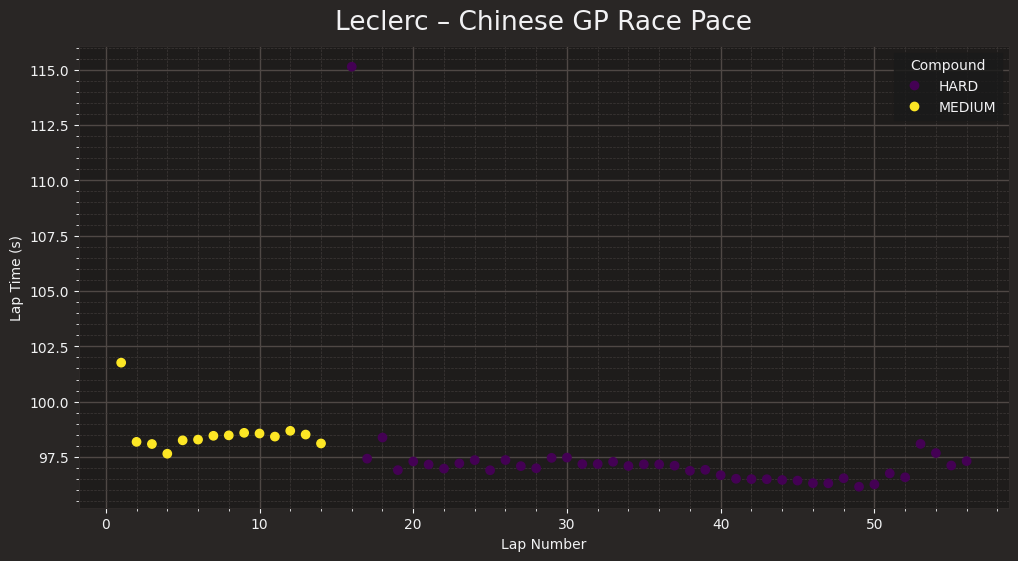

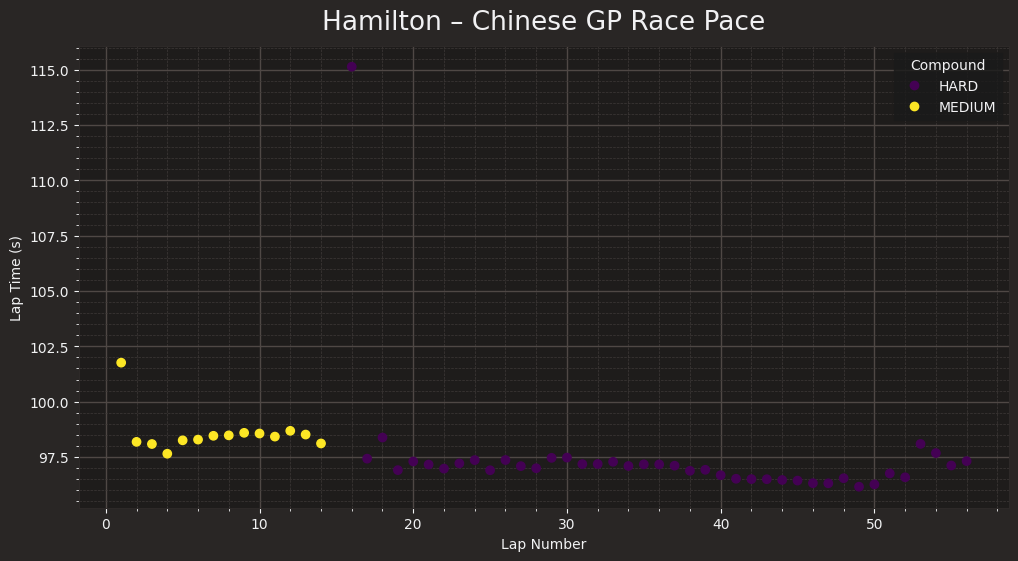

In [55]:
def plot_lap_time_vs_number(laps, driver_name):
    lap_times = laps['LapTime'].dt.total_seconds()
    compounds = laps['Compound']
    lap_numbers = laps['LapNumber']

    fig, ax = plt.subplots()
    scatter = ax.scatter(lap_numbers, lap_times, c=compounds.astype('category').cat.codes, cmap='viridis', label=driver_name)

    # Set compound color legend manually
    handles, _ = scatter.legend_elements(prop='colors')
    compound_labels = compounds.astype('category').cat.categories
    ax.legend(handles, compound_labels, title="Compound")

    ax.set_title(f"{driver_name} – Chinese GP Race Pace")
    ax.set_xlabel("Lap Number")
    ax.set_ylabel("Lap Time (s)")
    ax.grid(True)
    plt.show()

plot_lap_time_vs_number(lec_clean, "Leclerc")
plot_lap_time_vs_number(ham_clean, "Hamilton")

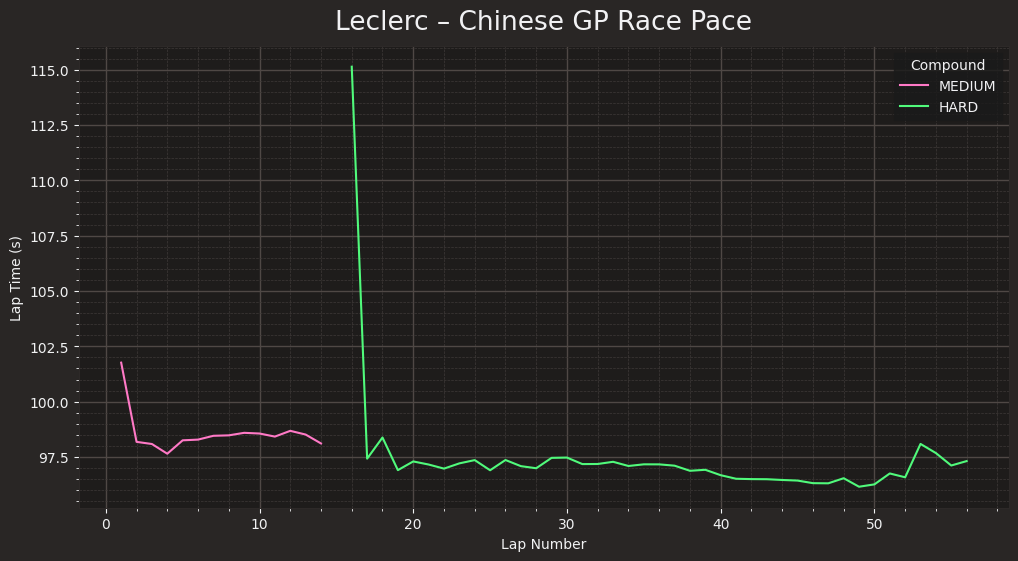

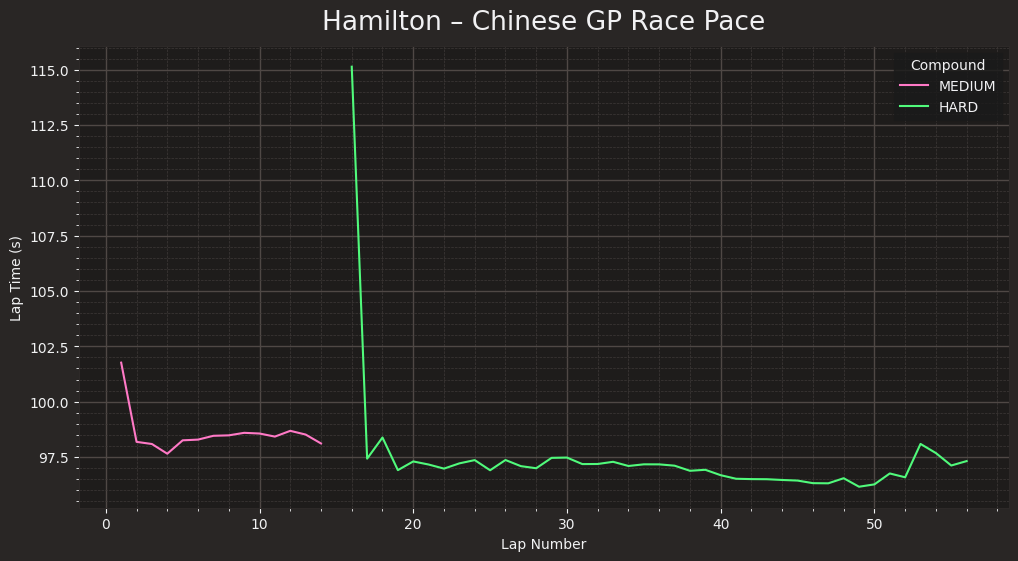

In [56]:
def plot_lap_time_vs_number(laps, driver_name):
    lap_times = laps['LapTime'].dt.total_seconds()
    compounds = laps['Compound']
    lap_numbers = laps['LapNumber']

    fig, ax = plt.subplots()

    # Plot each compound separately to maintain color coding
    for compound in compounds.unique():
        compound_mask = compounds == compound
        ax.plot(
            lap_numbers[compound_mask],
            lap_times[compound_mask],
            label=compound
        )

    ax.set_title(f"{driver_name} – Chinese GP Race Pace")
    ax.set_xlabel("Lap Number")
    ax.set_ylabel("Lap Time (s)")
    ax.legend(title="Compound")
    ax.grid(True)
    plt.show()

# Example usage
plot_lap_time_vs_number(lec_clean, "Leclerc")
plot_lap_time_vs_number(ham_clean, "Hamilton")
